In [15]:
#Import Necessary Libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [16]:
#Function 8
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 8.csv') 
columns = ['Input 1', 'Input 2','Input 3', 'Input 4', 'Input 5',
           'Input 6', 'Input 7', 'Input 8' ,'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
data

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Outputs
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [17]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Input 5'
                  ,'Input 6', 'Input 7', 'Input 8']])
Y = np.array(data[['Outputs']])


In [18]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Outputs
Input 1,1.000000,0.276627,0.237619,0.164203,0.142994,0.070105,0.302735,0.054966,-0.704497
Input 2,0.276627,1.000000,0.229186,-0.102314,0.000410,-0.073014,-0.050868,-0.272548,-0.357756
Input 3,0.237619,0.229186,1.000000,0.117059,-0.151989,-0.227428,0.060330,-0.033871,-0.719344
Input 4,0.164203,-0.102314,0.117059,1.000000,-0.030921,-0.031890,-0.060608,0.199363,-0.185045
Input 5,0.142994,0.000410,-0.151989,-0.030921,1.000000,0.051044,-0.005896,-0.030028,-0.010774
Input 6,0.070105,-0.073014,-0.227428,-0.031890,0.051044,1.000000,-0.040910,0.067374,0.103529
Input 7,0.302735,-0.050868,0.060330,-0.060608,-0.005896,-0.040910,1.000000,-0.072747,-0.430390
Input 8,0.054966,-0.272548,-0.033871,0.199363,-0.030028,0.067374,-0.072747,1.000000,0.101177
Outputs,-0.704497,-0.357756,-0.719344,-0.185045,-0.010774,0.103529,-0.430390,0.101177,1.000000


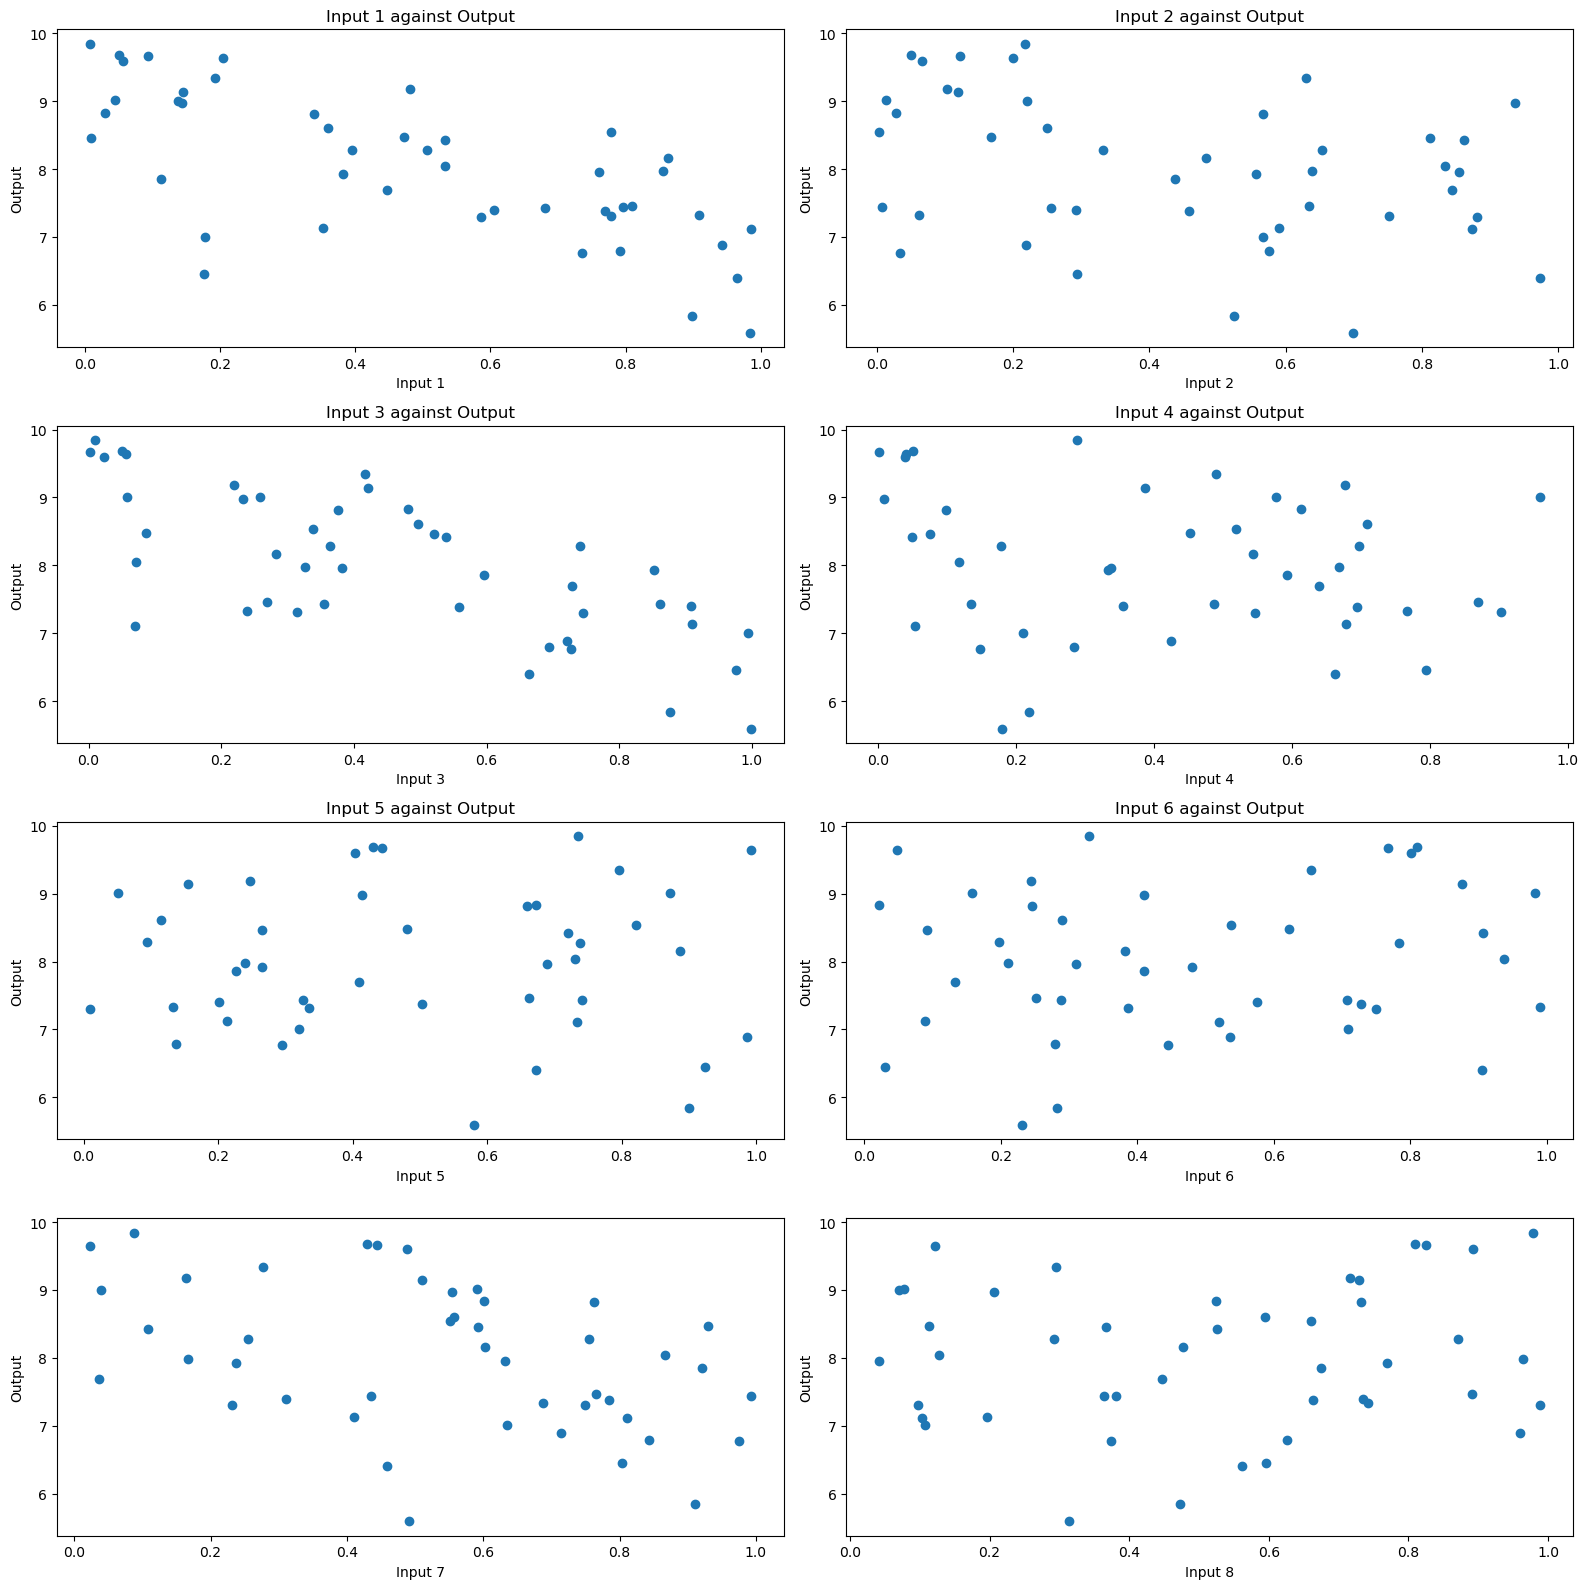

In [19]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4,2, figsize = (16,16))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)
ax[2][0].scatter(X[:,4], Y)
ax[2][1].scatter(X[:,5], Y)
ax[3][0].scatter(X[:,6], Y)
ax[3][1].scatter(X[:,7], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')
ax[2][0].set_title('Input 5 against Output')
ax[2][1].set_title('Input 6 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

ax[2][0].set_xlabel('Input 5')
ax[2][0].set_ylabel('Output')

ax[2][1].set_xlabel('Input 6')
ax[2][1].set_ylabel('Output')

ax[3][0].set_xlabel('Input 7')
ax[3][0].set_ylabel('Output')

ax[3][1].set_xlabel('Input 8')
ax[3][1].set_ylabel('Output')

plt.tight_layout()
plt.show()

In [20]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp_best = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
gp_best.fit(X,Y)
#Use latin hypercube sampling to create a set of candidate points 
d = 8
n = 900000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Fit the GP regressor to the candidate points
mu, std = gp_best.predict(grid, return_std = True)

In [21]:
#Calculating expected improvement
best_y = np.max(Y)
eta = 0.01
z = (mu - best_y - eta) / (std + 1e-12)
ei = (mu - best_y - eta ) * norm.cdf(z) + std * norm.pdf(z)
#Find Candidate value that maximises expected improvement 
best_idx = np.argmax(ei)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.15568 , 0.299078, 0.062464, 0.226614, 0.691137, 0.485902,
       0.259463, 0.477562])

In [31]:
#Calculate UCB as comparison
beta = 2.5#set exploration parameter
UCB = mu + beta * std
#Find Candidate value that maximises UCB
best_idx = np.argmax(UCB)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.006676, 0.14285 , 0.014612, 0.008493, 0.013195, 0.029041,
       0.146052, 0.709045])